In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np
import os
import json

np.load(
    "/home/kumargirish/data/ptbxl_data_sssd-ecg/d_tog_15_cn/labels/ptbxl_train_labels.npy"
).shape

In [ ]:
embedding_path = "/home/kumargirish/data/ptbxl/ptbxl_text_embed.csv"
target_embedding_path = "/home/kumargirish/data/ptbxl/ptbxl_text_embed_with_reduced.csv"

### Load data

In [ ]:
df = pd.read_csv(embedding_path)

In [ ]:
df[["scp_codes", "text_embed"]].head()

### Convert to 15 labels

In [ ]:
from label_utils import relabel_ndarray_of_71_label_arr_to_15_label_one_hot_arr, LABEL_15_NAMES

In [ ]:
labels_arr = df["scp_codes"].apply(
    lambda x: json.loads(x.replace("'", '"')).keys()
)
labels_arr.shape

In [ ]:
d_15_labels = relabel_ndarray_of_71_label_arr_to_15_label_one_hot_arr(labels_arr)
d_15_labels.shape

### Reduce embeddings

In [11]:
encodings = np.vstack(
    [np.array(x.strip("[]").split(",")).astype(float) for x in df["text_embed"]]
)
encodings.shape

(21797, 1536)

In [13]:
from sklearn.manifold import TSNE
import umap
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from sklearn.preprocessing import MinMaxScaler

/home/kumargirish/miniconda3/envs/MGB-MAIDAP/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
reducer_type = "umap"

#### 2d

In [15]:
if reducer_type == "tsne":
    reducer = TSNE(n_components=2)
elif reducer_type == "umap":
    reducer = umap.UMAP(n_components=2)

In [16]:
embeddings_2d = reducer.fit_transform(encodings)

/home/kumargirish/miniconda3/envs/MGB-MAIDAP/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [17]:
embeddings_2d = MinMaxScaler().fit_transform(embeddings_2d)

In [18]:
embeddings_2d.shape

(21797, 2)

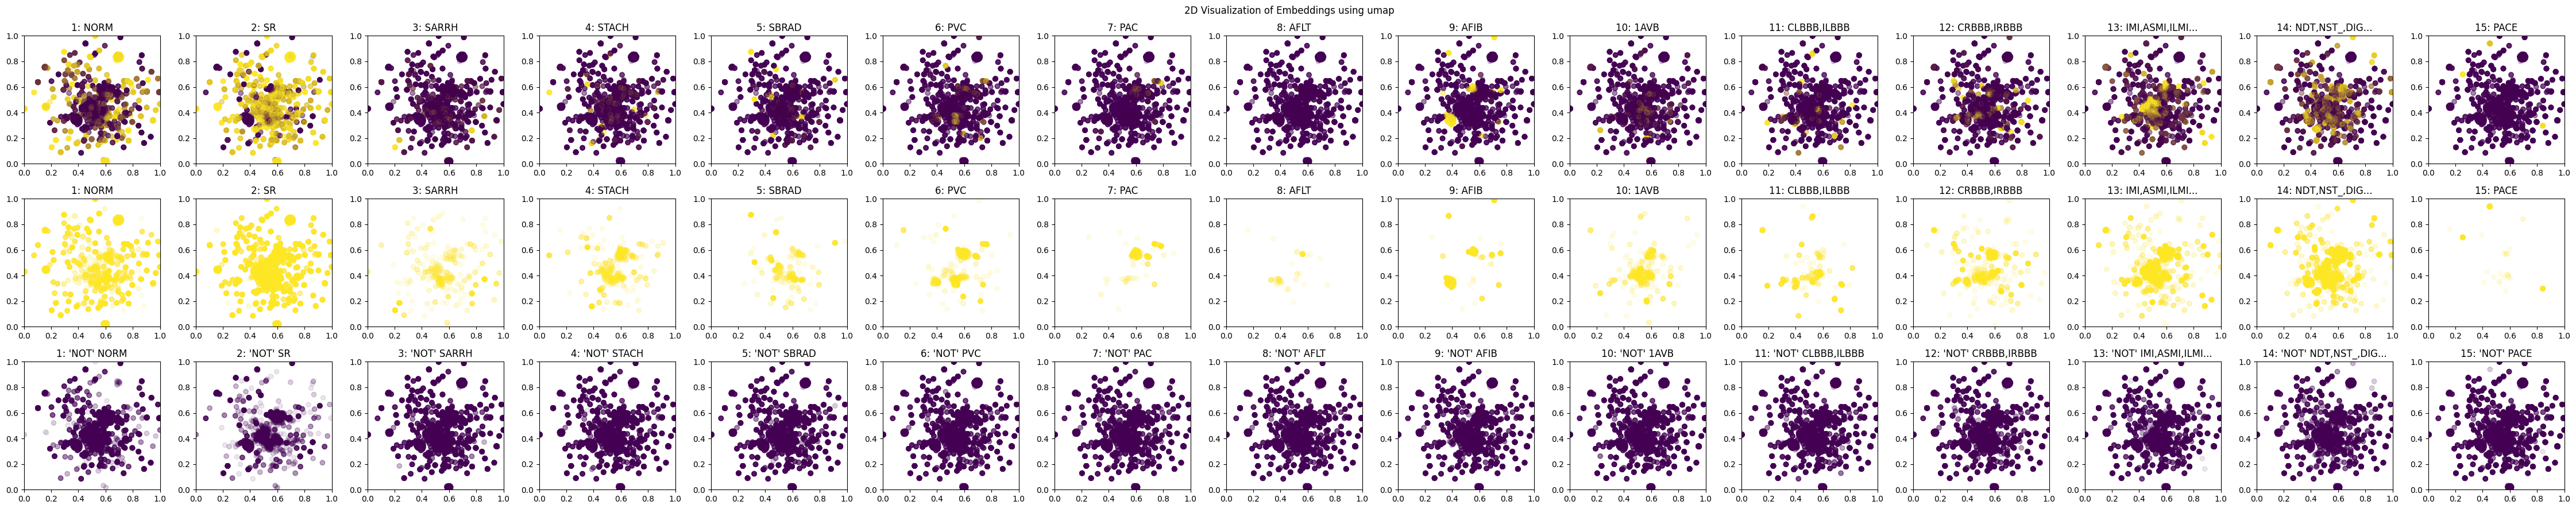

In [19]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 15, figsize=(45, 9))
viridis = mpl.colormaps['viridis'].resampled(2)

for label_idx, label_name_iter in enumerate(LABEL_15_NAMES):

    # Both together
    ax_to_plot = ax[0, label_idx]
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis((d_15_labels[:, label_idx] == 1)),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(0, 1)
    ax_to_plot.set_ylim(0, 1)

    # Positive for label
    ax_to_plot = ax[1, label_idx]
    d_indices = d_15_labels[:, label_idx] == 1
    title_for_label = f"{label_idx + 1}: {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.ones(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(0, 1)
    ax_to_plot.set_ylim(0, 1)

    # Negative for label
    ax_to_plot = ax[2, label_idx]
    d_indices = d_15_labels[:, label_idx] == 0
    title_for_label = f"{label_idx + 1}: \'NOT\' {label_name_iter}"
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=title_for_label,
        alpha=0.1,
        c=viridis(np.zeros(d_indices.sum())),
    )
    ax_to_plot.set_title(title_for_label)
    ax_to_plot.set_xlim(0, 1)
    ax_to_plot.set_ylim(0, 1)

plt.suptitle(f"2D Visualization of Embeddings using {reducer_type}")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

#### 3d

In [20]:
if reducer_type == "tsne":
    reducer = TSNE(n_components=3)
elif reducer_type == "umap":
    reducer = umap.UMAP(n_components=3)

In [21]:
embeddings_3d = reducer.fit_transform(encodings)

/home/kumargirish/miniconda3/envs/MGB-MAIDAP/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [22]:
embeddings_3d = MinMaxScaler().fit_transform(embeddings_3d)

In [23]:
embeddings_3d.shape

(21797, 3)

### Saving reduced embeddings

In [24]:
df.loc[:, "text_embed_2d"] = [str(x) for x in embeddings_2d.tolist()]

In [25]:
df.loc[:, "text_embed_3d"] = [str(x) for x in embeddings_3d.tolist()]

In [26]:
df[["text_embed", "text_embed_2d", "text_embed_3d"]].head()

,text_embed,text_embed_2d,text_embed_3d
0,"[-0.022633040323853493, -0.006966049782931805,...","[0.6812125444412231, 0.18638905882835388]","[0.9040407538414001, 0.5907195806503296, 0.410..."
1,"[-0.0300989281386137, -0.012552031315863132, 0...","[0.6660256385803223, 0.3652524948120117]","[0.6567263007164001, 0.685745358467102, 0.4110..."
2,"[-0.012751703150570393, -0.012646425515413284,...","[0.698142409324646, 0.8466458320617676]","[0.6829618215560913, 0.4888520836830139, 0.933..."
3,"[-0.012751703150570393, -0.012646425515413284,...","[0.6981161236763, 0.8368507623672485]","[0.693131148815155, 0.4956844449043274, 0.9525..."
4,"[-0.012751703150570393, -0.012646425515413284,...","[0.7019535303115845, 0.8364741802215576]","[0.6972293257713318, 0.48974376916885376, 0.93..."


In [27]:
df['text_embed'].iloc[0]

'[-0.022633040323853493, -0.006966049782931805, 0.0043206727132201195, -0.0008471663459204137, -0.031201547011733055, 0.009985554032027721, -0.01485914085060358, -0.017825670540332794, -0.0105748875066638, 0.005108657293021679, 0.00776065606623888, 0.04934506118297577, -0.012786542065441608, -0.0071647013537585735, -0.010058392770588398, -0.014422106556594372, 0.015587530098855495, 0.005323863122612238, 0.011813148856163025, 0.004582230467349291, 0.0067276679910719395, 0.030459914356470108, -0.009277029894292355, 0.004853721242398024, 0.0009171082638204098, 0.003973032347857952, 0.005582110490649939, -0.01614375412464142, 0.004118710290640593, 0.012329643592238426, 0.0026288230437785387, -0.0179316196590662, -0.016739709302783012, -0.008462558500468731, -0.014422106556594372, -0.01470021903514862, 0.0010023629292845726, 0.005939682945609093, 0.023705758154392242, 0.005588732194155455, 0.02452685311436653, -0.008727427572011948, -0.0008223348995670676, 0.016448352485895157, -0.015918616

In [28]:
df['text_embed_2d'].iloc[0]

'[0.6812125444412231, 0.18638905882835388]'

In [29]:
df.to_csv(target_embedding_path, index=False)

In [ ]:
np.load(
    "/home/kumargirish/data/ptbxl_data_sssd-ecg/d_tog_15_cn/labels/ptbxl_train_labels.npy"
).shape

### Visualize ECG

In [ ]:
x_arr = np.load(
    "/home/kumargirish/data/ptbxl_data_sssd-ecg/condition_all_separate_d+cn/data/ptbxl_train_data.npy"
)
x_arr.shape

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce embeddings to 2D
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(x_arr.reshape(x_arr.shape[0], -1))

In [ ]:
embeddings_2d.shape

In [ ]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 5, figsize=(15, 9))
for label_idx, label_name_iter in enumerate(labels_15):
    ax_to_plot = ax[label_idx // 5, label_idx % 5]
    ax_to_plot.scatter(
        embeddings_2d[:, 0],
        embeddings_2d[:, 1],
        label=f"Label {label_idx + 1}: {', '.join(label_name_iter)}",
        alpha=0.1,
        c=(d_15_labels[:, label_idx] == 1),
        cmap="viridis",
    )
    ax_to_plot.set_title(f"{label_idx + 1}: {', '.join(label_name_iter)}")
plt.suptitle("2D Visualization of Embeddings using t-SNE")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize the embeddings
fig, ax = plt.subplots(3, 5, figsize=(15, 9))
for label_idx, label_name_iter in enumerate(labels_15):
    ax_to_plot = ax[label_idx // 5, label_idx % 5]
    d_indices = d_15_labels[:, label_idx] == 1
    ax_to_plot.scatter(
        embeddings_2d[d_indices, 0],
        embeddings_2d[d_indices, 1],
        label=f"{label_idx + 1}: {', '.join(label_name_iter)}",
        alpha=0.1,
    )
    ax_to_plot.set_title(f"{label_idx + 1}: {', '.join(label_name_iter)}")
plt.suptitle("2D Visualization of Embeddings using t-SNE")
# plt.figlegend(loc="outside lower center", ncols=5)
plt.tight_layout()
plt.show()

## Visualize Synthetic Data

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import ecg_plot

exp_name = "condition_all_separate_d+cn"
# exp_name = "condition_all_separate_d"
split = "test"
real_data_folder = (
    f"/home/kumargirish/data/ptbxl_data_sssd-ecg/{exp_name}"
)
real_label_path = os.path.join(real_data_folder, f"labels/ptbxl_{split}_labels.npy")
real_data_path = os.path.join(real_data_folder, f"data/ptbxl_{split}_data.npy")

synth_path = f"/home/kumargirish/output_sssd-ecg/{exp_name}/{exp_name}/ch256_T200_betaT0.02/synth_{split}_data/"

In [ ]:
real_label = np.load(real_label_path)
print(real_label.shape)
real_data = np.load(real_data_path)
print(real_data.shape)

In [ ]:
# merge all the numpy data under from synth_path
npy_data_all = []
npy_label_all = []
for file in os.listdir(synth_path):
    if file.endswith("_labels.npy"):
        label_path = os.path.join(synth_path, file)
        npy_label_all.append(np.load(label_path))
    if file.endswith("_samples.npy"):
        npy_path = os.path.join(synth_path, file)
        npy_data_all.append(np.load(npy_path))

npy_data_all = np.concatenate(npy_data_all, axis=0)
npy_label_all = np.concatenate(npy_label_all, axis=0)
print(npy_label_all.shape)
print(npy_data_all.shape)

In [ ]:
label_order = ['1AVB', '2AVB', '3AVB', 'ABQRS', 'AFIB', 'AFLT', 'ALMI', 'AMI', 'ANEUR', 'ASMI', 'BIGU', 'CLBBB', 'CRBBB', 'DIG', 'EL', 'HVOLT', 'ILBBB', 'ILMI', 'IMI', 'INJAL', 'INJAS', 'INJIL', 'INJIN', 'INJLA', 'INVT', 'IPLMI', 'IPMI', 'IRBBB', 'ISCAL', 'ISCAN', 'ISCAS', 'ISCIL', 'ISCIN', 'ISCLA', 'ISC_', 'IVCD', 'LAFB', 'LAO/LAE', 'LMI', 'LNGQT', 'LOWT', 'LPFB', 'LPR', 'LVH', 'LVOLT', 'NDT', 'NORM', 'NST_', 'NT_', 'PAC', 'PACE', 'PMI', 'PRC(S)', 'PSVT', 'PVC', 'QWAVE', 'RAO/RAE', 'RVH', 'SARRH', 'SBRAD', 'SEHYP', 'SR', 'STACH', 'STD_', 'STE_', 'SVARR', 'SVTAC', 'TAB_', 'TRIGU', 'VCLVH', 'WPW']
new_label_order = ['1AVB', '2AVB', '3AVB', 'ALMI', 'AMI', 'ANEUR', 'ASMI', 'CLBBB', 'CRBBB', 'EL', 'ILBBB', 'ILMI', 'IMI', 'INJAL', 'INJAS', 'INJIL', 'INJIN', 'INJLA', 'IPLMI', 'IPMI', 'IRBBB', 'ISCAL', 'ISCAN', 'ISCAS', 'ISCIL', 'ISCIN', 'ISCLA', 'ISC_', 'IVCD', 'LAFB', 'LAO/LAE', 'LMI', 'LPFB', 'LVH', 'NORM', 'PMI', 'RAO/RAE', 'RVH', 'SEHYP', 'WPW', 'ABQRS', 'DIG', 'HVOLT', 'INVT', 'LNGQT', 'LOWT', 'LPR', 'LVOLT', 'NDT', 'NST_', 'NT_', 'PAC', 'PRC(S)', 'PVC', 'QWAVE', 'STD_', 'STE_', 'TAB_', 'VCLVH', 'AFIB', 'AFLT', 'BIGU', 'PACE', 'PSVT', 'SARRH', 'SBRAD', 'SR', 'STACH', 'SVARR', 'SVTAC', 'TRIGU']
labels_15_order = ["NORM", "SR", "SARRH", "STACH", "SBRAD", "PVC", "PAC", "AFLT", "AFIB", '1AVB', 'LBBB', 'RBBB', 'MI', 'ST', 'PACE']

In [ ]:
diffusets_label_transform = {
        'PAC': 'pac',
        'PVC': 'pvc',
        'CLBBB': 'lbbb',
        'ILBBB': 'lbbb',
        'CRBBB': 'rbbb',
        'IRBBB': 'rbbb',
        'SR': 'sn',
        'STACH': 'snt',
        'SBRAD': 'snb',
        'SARRH': 'sna',
        'AFLT': 'afl',
        'AFIB': 'af',
        'PACE': 'pacing',
        'IMI': 'mi',
        'ASMI': 'mi',
        'ILMI': 'mi',
        'AMI': 'mi',
        'ALMI': 'mi',
        'LMI': 'mi',
        'IPLMI': 'mi',
        'IPMI': 'mi',
        'PMI': 'mi',
        'NDT': 'st',
        'NST_': 'st',
        'DIG': 'st',
        'LNGQT': 'st',
        'ISC_': 'st',
        'ISCAL': 'st',
        'ISCIN': 'st',
        'ISCIL': 'st',
        'ISCAS': 'st',
        'ISCLA': 'st',
        'ANEUR': 'st',
        'EL': 'st',
        'ISCAN': 'st',
        '1AVB': 'abvi',
        '2AVB': 'abvi',
        '3AVB': 'abvi',
        'NORM': 'normal',
    }

In [ ]:
labels_15 = [["NORM"], ["SR"], ["SARRH"], ["STACH"], ["SBRAD"], ["PVC"], ["PAC"], ["AFLT"], ["AFIB"], ['1AVB'], ['CLBBB', 'ILBBB'], ['CRBBB', 'IRBBB'], ['IMI', 'ASMI', 'ILMI', 'AMI', 'ALMI', 'LMI', 'IPLMI', 'IPMI', 'PMI'], ['NDT', 'NST_', 'DIG', 'LNGQT', 'ISC_', 'ISCAL', 'ISCIN', 'ISCIL', 'ISCAS', 'ISCLA', 'ANEUR', 'EL', 'ISCAN'], ['PACE']]

In [ ]:
print(len(label_order))
print(len(new_label_order))
print(len(labels_15_order))

In [ ]:
def one_hot_to_str(label, label_order):
    label_str = []
    assert len(label) == len(label_order)
    for i, l in enumerate(label):
        if l == 1:
            label_str.append(label_order[i])
    return "-".join(label_str)

def str_to_one_hot(label_str, label_order):
    label = np.zeros(len(label_order))
    label_str_list = label_str.split("-")
    for index, label_name in enumerate(label_order):
        if label_name in label_str:
            label[index] = 1
    return label

def check_label_equal(label1, label_order1, label2, label_order2):
    label1_str = one_hot_to_str(label1, label_order1)
    label2_str = one_hot_to_str(label2, label_order2)
    print(label1_str, label2_str)
    return set(label1_str.split("-")) == set(label2_str.split("-"))

In [ ]:
import numpy as np

def relabel_71_to_15(one_hot_labels_71, labels_15, new_label_order):
    """
    Converts 71 one-hot encoded labels into 15 one-hot encoded labels.
    
    Args:
        one_hot_labels_71 (np.ndarray): Array of shape (2000, 71), where each row represents a one-hot encoding of 71 labels.
        labels_15 (list): A list of lists mapping 15 labels to corresponding 71-labels.
        new_label_order (list): A list defining the order of the 71 labels.
        
    Returns:
        np.ndarray: A (2000, 15) one-hot encoded label array.
    """
    num_samples = one_hot_labels_71.shape[0]
    num_new_labels = len(labels_15)
    
    # Initialize new one-hot labels array (2000, 15)
    one_hot_labels_15 = np.zeros((num_samples, num_new_labels), dtype=int)

    # Create a mapping from old labels to their indices
    label_to_index = {label: i for i, label in enumerate(new_label_order)}

    # Iterate through each sample
    for i in range(num_samples):
        for new_label_idx, label_group in enumerate(labels_15):
            for label in label_group:
                if label in label_to_index:
                    old_index = label_to_index[label]
                    if one_hot_labels_71[i, old_index] == 1:
                        one_hot_labels_15[i, new_label_idx] = 1

    return one_hot_labels_15

# Example usage:
# Assuming `one_hot_labels_71` is your (2000, 71) numpy array
# new_one_hot_labels_15 = relabel_71_to_15(one_hot_labels_71, labels_15, new_label_order)

In [ ]:
real_label_0 = real_label[0][:71]
real_label_0_str = one_hot_to_str(real_label[0][:71], new_label_order)
print(real_label_0, real_label_0_str)
real_label_15_0 = relabel_71_to_15(real_label, labels_15, new_label_order)[0]
print(real_label_15_0)
real_label_15_0_str = one_hot_to_str(real_label_15_0, labels_15_order)
print(real_label_15_0, real_label_15_0_str)


In [ ]:
import matplotlib.pyplot as plt

def plot_ecg_comparison(real_data, synth_data, label, lead_names=None):
    """
    Plots side-by-side ECG comparisons for real and synthetic data.

    Parameters:
    - real_data: np.array or list, shape (12, time_points), Real ECG signal data.
    - synth_data: np.array or list, shape (12, time_points), Synthetic ECG signal data.
    - label: str, title of the plot.
    - lead_names: list of str (optional), names of the 12 leads.
    """
    if lead_names is None:
        lead_names = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

    fig, axes = plt.subplots(12, 2, figsize=(25, 15), sharex=True, sharey=True)

    for i in range(12):
        # Plot real_data on the left
        axes[i, 0].plot(real_data[i])
        axes[i, 0].set_ylabel(lead_names[i], fontsize=10, fontweight='bold')
        axes[i, 0].set_yticks([])  # Remove y-axis ticks for clarity
        axes[i, 0].set_xticks([]) if i < 11 else axes[i, 0].set_xlabel("Time (ms)")

        # Plot synth_data on the right
        axes[i, 1].plot(synth_data[i])
        axes[i, 1].set_yticks([])  # Remove y-axis ticks
        axes[i, 1].set_xticks([]) if i < 11 else axes[i, 1].set_xlabel("Time (ms)")

    # Titles for columns
    axes[0, 0].set_title("Real Data", fontsize=12, fontweight='bold')
    axes[0, 1].set_title("Synthetic Data", fontsize=12, fontweight='bold')

    # Add main title
    plt.suptitle(label, fontsize=14, fontweight='bold')

    plt.tight_layout(rect=[0, 0, 1, 0.98])  # Adjust layout to fit title
    plt.show()

index = 0
plot_ecg_comparison(real_data[index].reshape(12, -1), npy_data_all[index].reshape(12, -1), one_hot_to_str(real_label[0][:71], new_label_order))